In [1]:
using Revise 
using Reexport 
includet("indirect.jl")
using Random
default(fontfamily="Times", guidefont=font(12), tickfont=font(10), legendfont=font(10))

function numerical_gradient(f, x; h=1e-7)
    n = length(x)
    grad = zeros(n)
    
    for i in 1:n
        # Create perturbation vectors
        x_plus = copy(x)
        x_minus = copy(x)
        
        x_plus[i] += h
        x_minus[i] -= h
        
        # Central difference: (f(x+h) - f(x-h)) / (2h)
        grad[i] = (f(x_plus) - f(x_minus)) / (2h)
    end
    
    return grad
end

numerical_gradient (generic function with 1 method)

In [2]:
U_goal = GATES.H
H_drive = [PAULIS.X, PAULIS.Y, PAULIS.Z]
n_controls = 3
n_timesteps = 40

sys = QuantumSystem(H_drive)

Δt = 0.2    
a_bound = 1.0
da_bound = 1.0 
dda_bound = 2.0 

a_smooth  = random_smooth_controls(n_controls, n_timesteps, a_bound, da_bound, dda_bound)


3×40 Matrix{Float64}:
 0.0  -0.0476453  -0.0879793  -0.115272  …  -0.0624296  -0.0328842  0.0
 0.0  -0.111418   -0.215557   -0.305522     -0.043621   -0.0240306  0.0
 0.0  -0.108151   -0.205013   -0.280869     -0.03757    -0.017477   0.0

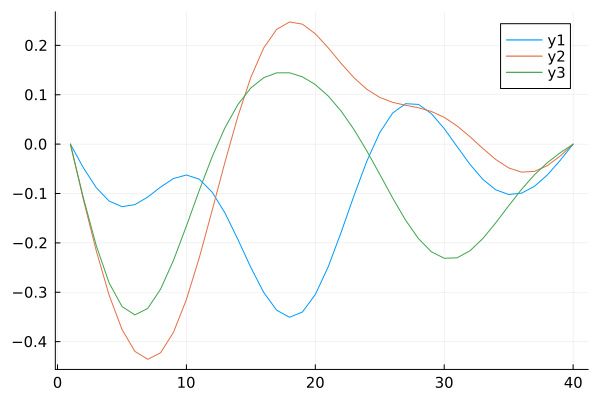

In [3]:
### Plot the initial trajectory 
p = Plots.plot(a_smooth[1,:])
Plots.plot!(p, a_smooth[2,:])
Plots.plot!(p, a_smooth[3,:])

In [4]:
smooth_prob = UnitarySmoothPulseProblem(sys, U_goal, n_timesteps, Δt; a_guess = a_smooth);
traj = smooth_prob.trajectory 
datavec = [vec(a_smooth'); Δt]

    constructing UnitarySmoothPulseProblem...
	using integrator: typeof(UnitaryIntegrator)
	control derivative names: [:da, :dda]
	applying timesteps_all_equal constraint: Δt


121-element Vector{Float64}:
  0.0
 -0.0476453225646186
 -0.08797929068848272
 -0.11527171433108471
 -0.12662095935081338
 -0.12260367992866653
 -0.10718802965911917
 -0.08692530753316842
 -0.06958529988980708
 -0.0625159753189971
  ⋮
 -0.19112640524574084
 -0.15938555753630007
 -0.12495935099324428
 -0.0916412589527452
 -0.062128061303110035
 -0.037570032952912204
 -0.017477022767273354
  0.0
  0.2

Regularization

In [5]:
R_a = 1
R_da = 2
R_dda = 3
reg = QuadraticRegularizer(:a, traj, R_a;)
reg += QuadraticRegularizer(:da, traj, R_da;)
reg += QuadraticRegularizer(:dda, traj, R_dda;)

reg.L(traj.datavec)

1.0983070437662341

In [6]:
control_regularization_objective(n_controls, R_a, R_da, R_dda)(datavec)

1.0983070437662343

In [7]:
norm(ForwardDiff.gradient(v -> control_regularization_objective(n_controls, R_a, R_da, R_dda)(v), datavec) - control_regularization_grad(n_controls, R_a, R_da, R_dda)(datavec))

2.5532856470704764e-15

Fidelity

In [8]:
Q = 50.0
fid = UnitaryInfidelityObjective(U_goal, :Ũ⃗, traj; Q=Q)
fid.L(traj.datavec)

36.094919112131464

In [9]:
norm(numerical_gradient(fid.L, traj.datavec)- fid.∇L(traj.datavec))

3.3701354595905286e-8

In [10]:
unitary_infidelity_objective(n_controls, sys, Q, U_goal)(datavec)

36.09491911213149

In [11]:
norm(ForwardDiff.gradient(v -> unitary_infidelity_objective(n_controls, sys, Q, U_goal)(v), datavec) - unitary_infidelity_grad(n_controls, sys, Q, U_goal)(datavec))

5.182845983810576e-14

Toggle

In [12]:
H_err = a -> [PAULIS.X] #a[2] * PAULIS.Y]
∂H_err = a-> [[spzeros(2,2), spzeros(2,2), spzeros(2,2)]]#, [spzeros(2,2), PAULIS.Y, spzeros(2,2)]]
Q_t = 1.0
Q = 0.0

varsys = VariationalQuantumSystem(
    a -> a[1] * PAULIS.X + a[2] * PAULIS.Y + a[3] * PAULIS.Z,
    Function[a -> PAULIS.X],#, a[2] * PAULIS.Y],
    3
)

tog  = TogglingObjective(H_err, ∂H_err, traj; Q_t=Q_t)
tog.L(traj.datavec)


45.899193151147585

In [13]:
toggle_objective(n_controls, varsys, Q_t)(datavec)

45.899193151147585

In [14]:
norm(ForwardDiff.gradient(v -> toggle_objective(n_controls, varsys, Q_t)(v), datavec) - toggle_grad(n_controls, varsys, Q_t)(datavec))

2.2966245738898465e-13

In [15]:
norm(numerical_gradient(tog.L, traj.datavec)- tog.∇L(traj.datavec))

6.252920389666895e-7

Variational sensitivity 

In [16]:
Q_r =1.0

varsys = VariationalQuantumSystem(
    a -> a[1] * PAULIS.X + a[2] * PAULIS.Y + a[3] * PAULIS.Z,
    Function[a -> PAULIS.X],#, a -> a[2] * PAULIS.Y],
    3
)

var_prob = UnitaryVariationalProblem(varsys, U_goal, n_timesteps, Δt; a_guess = a_smooth);

sense  = UnitarySensitivityObjective(
            :Ũ⃗ᵥ1, 
            var_prob.trajectory, 
            [n_timesteps]; 
            Qs=[Q_r], 
        )

sense.L(var_prob.trajectory.datavec)


    constructing UnitaryVariationalProblem...
	using integrator: typeof(VariationalUnitaryIntegrator)
	total variational parameters: 1
	control derivative names: [:da, :dda]
	applying timesteps_all_equal constraint: Δt


46.343297372292525

In [17]:
variational_infidelity_sensitivity_objective(n_controls, varsys, Q, Q_r, U_goal)(datavec)

46.343297372292426

In [18]:
norm(ForwardDiff.gradient(v -> variational_infidelity_sensitivity_objective(n_controls, varsys, Q, Q_r, U_goal)(v), datavec) - variational_infidelity_sensitivity_grad(n_controls, varsys, Q, Q_r, U_goal)(datavec))

2.293896031385105e-13

In [19]:
norm(numerical_gradient(sense.L, var_prob.trajectory.datavec)- sense.∇L(var_prob.trajectory.datavec))

4.9508325507741476e-8

### IGNORE ###

### Full Problems ###

In [ ]:
Q = 100.0 
R_a = R_da = R_dda = 1e-2
p = UnitarySmoothPulseProblem(sys, U_goal, n_timesteps, Δt; a_guess = a_smooth, Q = Q, R_a = R_a, R_da = R_da, R_dda = R_dda);
p.objective.L(p.trajectory.datavec)

In [ ]:
indirect_obj = unitary_smooth_objective(n_controls, sys, U_goal, R_a, R_da, R_dda, Q)
indirect_grad = unitary_smooth_grad(n_controls, sys, U_goal, R_a, R_da, R_dda, Q)
indirect_obj(datavec)

In [ ]:
norm(ForwardDiff.gradient(v -> indirect_obj(v), datavec) - indirect_grad(datavec))

In [ ]:
p = UnitaryToggleProblem(varsys, U_goal, n_timesteps, Δt; a_guess = a_smooth, Q = Q, R_a = R_a, R_da = R_da, R_dda = R_dda, Q_t = Q_t);
p.objective.L(p.trajectory.datavec)

In [ ]:
indirect_obj = unitary_toggle_objective(n_controls, varsys, U_goal, R_a, R_da, R_dda, Q, Q_t)
indirect_grad = unitary_toggle_grad(n_controls, varsys, U_goal, R_a, R_da, R_dda, Q, Q_t)
indirect_obj(datavec)

In [ ]:
norm(ForwardDiff.gradient(v -> indirect_obj(v), datavec) - indirect_grad(datavec))

In [ ]:
p = UnitaryVariationalProblem(varsys, U_goal, n_timesteps, Δt; a_guess = a_smooth, Q = Q, R_a = R_a, R_da = R_da, R_dda = R_dda, robust_times = [[n_timesteps], [n_timesteps]], Q_r =Q_r);
p.objective.L(p.trajectory.datavec)

In [ ]:
indirect_obj = unitary_variational_objective(n_controls, varsys, U_goal, R_a, R_da, R_dda, Q, Q_r)
indirect_grad = unitary_variational_grad(n_controls, varsys, U_goal, R_a, R_da, R_dda, Q, Q_r)
indirect_obj(datavec)

In [ ]:
norm(ForwardDiff.gradient(v -> indirect_obj(v), datavec) - indirect_grad(datavec))

In [ ]:
function upsample_constant_controls(vals::AbstractArray; factor::Int=2)
    vals_up = repeat(vals, inner=factor)
    return vals_up
end

function upsample_matrix(datavec::AbstractArray; factor::Int=2)
    controls_vec, Δt = datavec[1:end-1], datavec[end]
    controls = vec_to_components(controls_vec, n_controls)
    new_controls = []
    for c in eachrow(controls)
        new_c = upsample_constant_controls(c; factor=factor)
        push!(new_controls, new_c)
    end
    return [reduce(vcat, new_controls) ; Δt/factor]
    
end

In [ ]:
upsample_matrix(datavec; factor = 3)

In [ ]:
f = 1
(variational_infidelity_sensitivity_objective(n_controls, varsys, 0, 1.0, U_goal)(upsample_matrix(datavec; factor = f)))

In [ ]:
toggle_objective(n_controls, varsys, Q_t)(upsample_matrix(datavec; factor = f))